# Question 1 : Impact Relatif des Facteurs sur le Bonheur

**Objectif :** Visualiser l'influence spécifique de l'économie, du soutien social, de la santé, de la liberté, de la générosité et de la corruption sur le score de bonheur (`Life Ladder`).

In [12]:
# Importations essentielles
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Style graphique (optionnel)
sns.set_theme(style="whitegrid")

print("Bibliothèques importées.")

Bibliothèques importées.


In [13]:
# --- Chargement initial unique des données ---

# Chemin du fichier
file_path = 'CSVs/world_happiness_report_2024.csv' 
# Si vous avez téléversé le dossier WorldHappinessReport/, le chemin pourrait être :
# file_path = 'WorldHappinessReport/CSVs/world_happiness_report_2024.csv'

# Charger TOUTES les colonnes utiles pour les questions (ou toutes par simplicité)
try:
    df_whr_full = pd.read_csv(file_path)
    print(f"Données complètes chargées depuis {file_path}. Dimensions: {df_whr_full.shape}")
    
    # Afficher un aperçu et les infos (optionnel)
    # display(df_whr_full.head())
    # print("\nInfos sur le DataFrame complet:")
    # df_whr_full.info()

except FileNotFoundError:
    print(f"ERREUR : Le fichier {file_path} n'a pas été trouvé. Vérifiez le chemin.")
    # Arrêter potentiellement l'exécution si le fichier n'est pas trouvé
    df_whr_full = None 
except Exception as e:
    print(f"Une erreur est survenue lors du chargement: {e}")
    df_whr_full = None

Données complètes chargées depuis CSVs/world_happiness_report_2024.csv. Dimensions: (2363, 11)


Préparation pour Q1: 2103 observations utilisées après nettoyage des NaN.
Formule Q1 utilisée : Q("Life Ladder") ~ Q("Log GDP per capita") + Q("Social support") + Q("Healthy life expectancy at birth") + Q("Freedom to make life choices") + Q("Generosity") + Q("Perceptions of corruption")
Modèle de régression Q1 ajusté.
Génération du graphique des coefficients Q1...


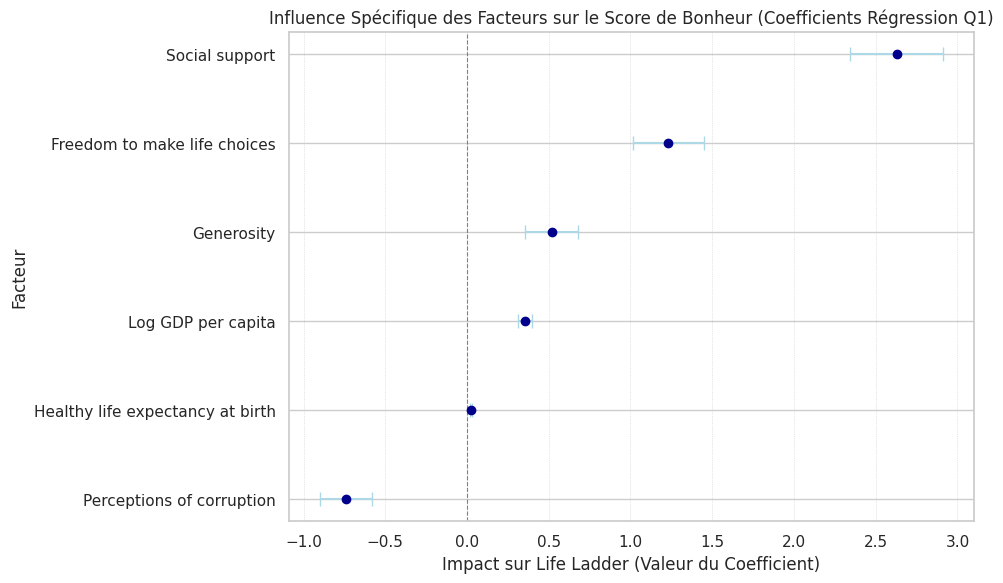

In [14]:
# --- Analyse et Graphique Principal Q1 (Coefficient Plot) ---

if df_whr_full is not None: # Vérifie si le chargement a réussi
    
    # Colonnes nécessaires SPÉCIFIQUEMENT pour la régression Q1
    colonnes_regression_q1 = [
        'Life Ladder',
        'Log GDP per capita',
        'Social support',
        'Healthy life expectancy at birth',
        'Freedom to make life choices',
        'Generosity',
        'Perceptions of corruption'
    ]

    # Préparation des données A LA VOLEE pour Q1: sélectionner + nettoyer NaN
    df_q1_analysis_data = df_whr_full[colonnes_regression_q1].dropna()
    print(f"Préparation pour Q1: {len(df_q1_analysis_data)} observations utilisées après nettoyage des NaN.")

    # Définir la formule de régression avec Q()
    predictor_cols_q = [f'Q("{col}")' for col in colonnes_regression_q1 if col != 'Life Ladder']
    formula_q1 = f'Q("Life Ladder") ~ {" + ".join(predictor_cols_q)}'
    print(f"Formule Q1 utilisée : {formula_q1}")

    try:
        # Ajuster le modèle OLS sur les données nettoyées pour Q1
        model_q1 = smf.ols(formula=formula_q1, data=df_q1_analysis_data)
        results_q1 = model_q1.fit()
        print("Modèle de régression Q1 ajusté.")

        # --- Création du Graphique des Coefficients (identique à avant) ---
        print("Génération du graphique des coefficients Q1...")
        coeffs = results_q1.params.drop('Intercept')
        conf_int = results_q1.conf_int().drop('Intercept')
        coeffs.index = [name.replace('Q("', '').replace('")', '') for name in coeffs.index]
        conf_int.index = [name.replace('Q("', '').replace('")', '') for name in conf_int.index]
        coeffs_sorted = coeffs.sort_values()
        conf_int_sorted = conf_int.loc[coeffs_sorted.index]
        
        plt.figure(figsize=(10, 6))
        err = (conf_int_sorted[1] - conf_int_sorted[0]) / 2
        plt.errorbar(coeffs_sorted, coeffs_sorted.index, xerr=err, fmt='o', color='darkblue', ecolor='lightblue', capsize=5, label='Coefficient (IC 95%)')
        plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
        plt.title('Influence Spécifique des Facteurs sur le Score de Bonheur (Coefficients Régression Q1)')
        plt.xlabel('Impact sur Life Ladder (Valeur du Coefficient)')
        plt.ylabel('Facteur')
        plt.grid(axis='x', linestyle=':', linewidth=0.5)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Une erreur est survenue lors de l'analyse ou la visualisation Q1 : {e}")
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q1 annulée.")

**Conclusion (Basée sur le graphique des coefficients)**

Le graphique ci-dessus illustre l'influence spécifique estimée de chaque facteur sur le score de bonheur (`Life Ladder`), une fois l'effet des autres facteurs pris en compte :

* **Signification :** Tous les facteurs sont statistiquement significatifs, car leurs intervalles de confiance (barres horizontales claires) ne coupent pas la ligne verticale à zéro.
* **Impacts Positifs (points à droite de zéro) :**
    * Le `Social support` (soutien social) se distingue nettement avec le coefficient positif le plus élevé (le point bleu le plus à droite, vers +2.6), indiquant l'impact positif le plus fort.
    * La `Freedom to make life choices` (liberté de choix) montre également un impact positif très important (vers +1.2).
    * Viennent ensuite, avec des impacts positifs notables mais moindres, la `Generosity` (générosité, vers +0.5) et le `Log GDP per capita` (PIB logarithmique, vers +0.35).
    * La `Healthy life expectancy at birth` (espérance de vie en bonne santé) a l'impact positif le plus faible parmi les facteurs significatifs (proche de zéro, vers +0.03).
* **Impact Négatif (point à gauche de zéro) :**
    * La `Perceptions of corruption` (perception de la corruption) est le seul facteur ayant un impact négatif significatif (vers -0.75). Une perception élevée de la corruption est donc associée à un score de bonheur plus bas.

En résumé, ce graphique met en évidence l'importance prépondérante du soutien social et de la liberté perçue pour expliquer le bonheur. L'économie, la générosité et la santé y contribuent aussi positivement mais à des degrés divers, tandis que la perception de la corruption agit clairement comme un frein au bien-être tel que mesuré par le `Life Ladder`.

# Question 2 : Pays "Hors Normes" Économiques

**Objectif :** Identifier les pays dont le score de bonheur (`Life Ladder`) est supérieur à ce que leur niveau de PIB par habitant (`Log GDP per capita`) laisserait présager.

In [15]:
# --- Préparation et Analyse des Résidus Q2 ---

if df_whr_full is not None: # Vérifie si le chargement initial a réussi
    
    # 1. Sélectionner les données les plus récentes par pays depuis df_whr_full
    df_latest = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
    print(f"Préparation pour Q2: Données les plus récentes sélectionnées pour {len(df_latest)} pays.")

    # 2. Nettoyer les NaN SPÉCIFIQUEMENT pour les colonnes de Q2 (Life Ladder, Log GDP)
    colonnes_q2 = ['Life Ladder', 'Log GDP per capita', 'Country', 'year'] # Inclure Country/Year pour les labels
    df_q2_analysis_data = df_latest[colonnes_q2].dropna(subset=['Life Ladder', 'Log GDP per capita'])
    print(f"Préparation pour Q2: {len(df_q2_analysis_data)} observations utilisées après nettoyage des NaN pour LL et GDP.")

    # 3. Régression simple : Bonheur ~ PIB sur les données nettoyées de Q2
    formula_q2 = 'Q("Life Ladder") ~ Q("Log GDP per capita")'
    model_q2 = smf.ols(formula=formula_q2, data=df_q2_analysis_data)
    results_q2 = model_q2.fit()
    print("Régression simple Q2 (Bonheur ~ PIB) ajustée.")

    # 4. Calculer les résidus sur les données nettoyées de Q2
    df_q2_analysis_data['Predicted Happiness (GDP)'] = results_q2.predict(df_q2_analysis_data)
    df_q2_analysis_data['Residual (Happiness vs GDP)'] = df_q2_analysis_data['Life Ladder'] - df_q2_analysis_data['Predicted Happiness (GDP)']

    # 5. Identifier les N pays les plus "surperformants"
    N = 15 
    top_overperformers = df_q2_analysis_data.nlargest(N, 'Residual (Happiness vs GDP)')
    
    print(f"\nTop {N} pays avec un bonheur supérieur aux prédictions basées sur le PIB (Q2):")
    
    # ---- LIGNE CORRIGEE ----
    # Appliquer le format uniquement aux colonnes numériques spécifiées dans 'subset'
    display(top_overperformers[['Country','Life Ladder', 'Log GDP per capita', 'Residual (Happiness vs GDP)']]
            .style.format("{:.2f}", subset=['Life Ladder', 'Log GDP per capita', 'Residual (Happiness vs GDP)']))
    # -------------------------

else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q2 annulée.")

Préparation pour Q2: Données les plus récentes sélectionnées pour 165 pays.
Préparation pour Q2: 153 observations utilisées après nettoyage des NaN pour LL et GDP.
Régression simple Q2 (Bonheur ~ PIB) ajustée.

Top 15 pays avec un bonheur supérieur aux prédictions basées sur le PIB (Q2):


,Country,Life Ladder,Log GDP per capita,Residual (Happiness vs GDP)
1442,Mozambique,5.70,7.15,1.89
490,Costa Rica,7.38,10.02,1.42
1533,Nicaragua,6.36,8.69,1.40
1116,Kosovo,6.88,9.48,1.32
2277,Uzbekistan,6.38,9.03,1.16
632,El Salvador,6.48,9.17,1.15
680,Finland,7.70,10.81,1.14
1369,Mexico,7.01,9.90,1.13
803,Guatemala,6.42,9.14,1.11
1147,Kyrgyzstan,5.91,8.57,1.03


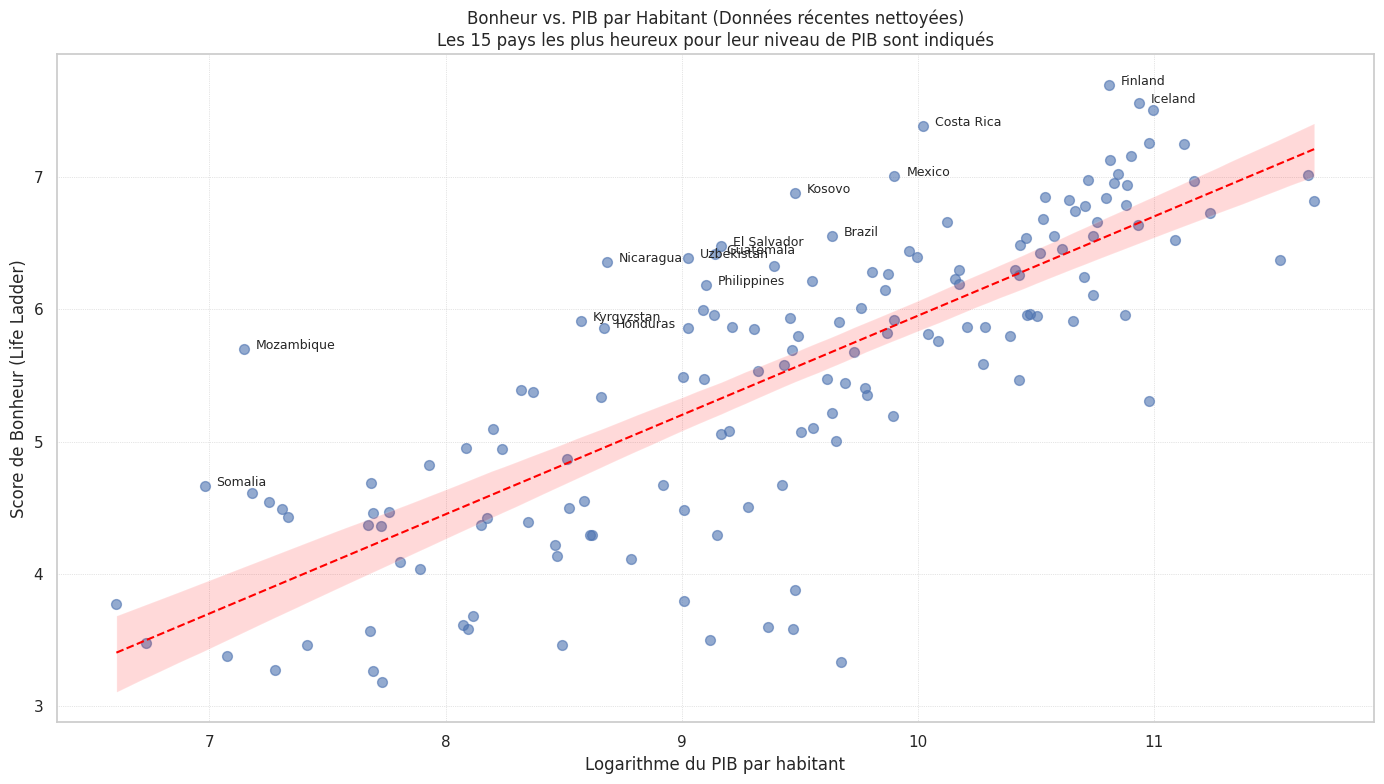

In [16]:
# --- Visualisation Q2 : Scatter Plot avec Outliers ---

# Vérifier si les dataframes nécessaires existent (générés dans la cellule précédente)
q2_data_exists = 'df_q2_analysis_data' in locals() and 'top_overperformers' in locals()

if df_whr_full is not None and q2_data_exists:
    
    plt.figure(figsize=(14, 8))
    
    # Nuage de points + droite de régression en utilisant les données Q2 nettoyées
    ax = sns.regplot(x='Log GDP per capita', y='Life Ladder', data=df_q2_analysis_data,
                     scatter_kws={'alpha': 0.6, 's': 50}, 
                     line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 1.5}) 

    # Ajouter les labels pour les N pays surperformants (depuis top_overperformers)
    # Assurez-vous que top_overperformers contient les colonnes x, y, et Country
    for i, country_data in top_overperformers.iterrows():
        plt.text(country_data['Log GDP per capita'] + 0.05, 
                 country_data['Life Ladder'], 
                 country_data['Country'], 
                 fontsize=9)

    plt.title(f'Bonheur vs. PIB par Habitant (Données récentes nettoyées)\nLes {N} pays les plus heureux pour leur niveau de PIB sont indiqués')
    plt.xlabel('Logarithme du PIB par habitant')
    plt.ylabel('Score de Bonheur (Life Ladder)')
    plt.grid(True, linestyle=':', linewidth=0.5)
    plt.tight_layout()
    plt.show()

elif df_whr_full is None:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Visualisation Q2 annulée.")
else:
    print("Les données nécessaires ('df_q2_analysis_data', 'top_overperformers') n'ont pas été créées. Visualisation Q2 annulée.")

**Conclusion (Basée sur le graphique et les résidus Q2)**

Le graphique ci-dessus visualise le score de bonheur (`Life Ladder`) en fonction de la richesse économique (`Log GDP per capita`) pour les données les plus récentes. La ligne rouge pointillée représente la tendance générale : plus un pays est riche, plus son score de bonheur tend à être élevé.

Cependant, de nombreux pays s'écartent de cette tendance. Ceux situés nettement **au-dessus** de la ligne rouge sont les "surperformants" : ils affichent un niveau de bonheur plus élevé que ce que leur PIB seul ne laisserait supposer. Les 15 pays avec le plus grand écart positif sont nommés sur le graphique et listés dans le tableau précédent.

Parmi ces pays qui "surpassent" leur performance économique en termes de bonheur, on note :

* **Une forte présence latino-américaine :** Le **Costa Rica** est très nettement au-dessus de la ligne, suivi par le **Nicaragua**, **El Salvador**, le **Mexique**, le **Guatemala**, le **Honduras** et le **Brésil**.
* **Des cas surprenants à faible revenu :** Le **Mozambique** et la **Somalie** affichent un bonheur remarquablement plus élevé que prédit par leur très faible PIB.
* **Des pays d'Europe et d'Asie Centrale :** Le **Kosovo**, l'**Ouzbékistan** et le **Kirghizstan** se distinguent également. Les **Philippines** sont aussi dans ce groupe.
* **Des pays nordiques déjà riches :** La **Finlande** et l'**Islande**, bien que déjà très riches, parviennent à être *encore plus* heureuses que ce que leur niveau de PIB élevé prédirait.

Ces résultats suggèrent fortement que si la richesse contribue au bonheur, elle n'en est pas le seul déterminant. Des facteurs comme la qualité des liens sociaux, la liberté individuelle, la confiance, la générosité (analysés dans la Question 1) jouent un rôle crucial et permettent à certains pays, notamment en Amérique Latine mais aussi ailleurs, d'atteindre un bien-être subjectif élevé malgré un niveau de richesse parfois modeste ou moyen. Pour les pays déjà riches comme la Finlande ou l'Islande, cela indique une efficacité particulière à convertir la richesse en bien-être subjectif grâce à ces autres facteurs.

# Question 3 : Disparités Régionales du Bonheur

**Objectif :** Examiner comment le score de bonheur (`Life Ladder`) et ses composantes principales (PIB, soutien social, santé, liberté, générosité, corruption) varient en moyenne d'une région géographique à l'autre.

In [17]:
# --- Préparation des Données Régionales ---

if df_whr_full is not None: # Vérifie si le chargement initial (Cellule 3) a réussi
    
    # 1. Charger les données de régions depuis le fichier CPI
    cpi_file_path = 'CSVs/CPI2023_global_results_trends.csv'
    # Si dossier WorldHappinessReport/ : 'WorldHappinessReport/CSVs/CPI2023_global_results_trends.csv'
    try:
        df_regions = pd.read_csv(cpi_file_path, usecols=['Country', 'Region'])
        print(f"Données régionales chargées depuis {cpi_file_path}. {len(df_regions)} pays trouvés.")
        # Nettoyer les noms de région si nécessaire (optionnel)
        # df_regions['Region'] = df_regions['Region'].str.strip() 
    except FileNotFoundError:
        print(f"ERREUR: Le fichier CPI {cpi_file_path} est introuvable.")
        df_regions = None
    except Exception as e:
        print(f"Erreur lors du chargement des régions: {e}")
        df_regions = None

    if df_regions is not None:
        # 2. Sélectionner les données les plus récentes par pays depuis df_whr_full
        df_latest = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
        print(f"Données les plus récentes sélectionnées pour {len(df_latest)} pays du WHR.")

        # 3. Fusionner les données récentes du WHR avec les informations de région
        #    ATTENTION: La fusion sur 'Country' peut échouer si les noms ne correspondent pas exactement.
        df_merged_regions = pd.merge(df_latest, df_regions, on='Country', how='left')
        
        # Vérifier combien de pays n'ont pas eu de correspondance de région
        unmatched_countries = df_merged_regions[df_merged_regions['Region'].isnull()]['Country'].nunique()
        if unmatched_countries > 0:
            print(f"Attention: {unmatched_countries} pays n'ont pas pu être associés à une région (vérifiez les noms de pays).")
        
        # Retirer les pays sans région pour l'analyse régionale
        df_regional_data = df_merged_regions.dropna(subset=['Region'])
        print(f"{len(df_regional_data)} observations avec informations régionales disponibles pour l'analyse.")

        # 4. Calculer les scores moyens par région pour les variables clés
        colonnes_analyse_q3 = [
            'Life Ladder', 'Log GDP per capita', 'Social support', 
            'Healthy life expectancy at birth', 'Freedom to make life choices', 
            'Generosity', 'Perceptions of corruption'
        ]
        # Calculer la moyenne pour chaque colonne numérique pertinente, groupée par Région
        # Note: .mean(numeric_only=True) gère automatiquement les colonnes non numériques
        regional_means = df_regional_data.groupby('Region')[colonnes_analyse_q3].mean().reset_index()

        print("\nScores moyens par région :")
        # Afficher le tableau des moyennes régionales
        display(regional_means.round(2)) # Arrondir pour une meilleure lisibilité
        
    else:
        print("Analyse régionale annulée car les données régionales n'ont pas pu être chargées.")
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q3 annulée.")

Données régionales chargées depuis CSVs/CPI2023_global_results_trends.csv. 180 pays trouvés.
Données les plus récentes sélectionnées pour 165 pays du WHR.
Attention: 10 pays n'ont pas pu être associés à une région (vérifiez les noms de pays).
155 observations avec informations régionales disponibles pour l'analyse.

Scores moyens par région :


,Region,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption
0,AME,6.16,9.63,0.84,66.00,0.81,-0.02,0.77
1,AP,5.31,9.42,0.76,65.14,0.82,0.13,0.70
2,ECA,5.77,9.59,0.86,66.09,0.83,0.05,0.76
3,MENA,5.36,9.97,0.75,65.28,0.69,0.01,0.75
4,SSA,4.26,8.06,0.65,56.54,0.70,0.03,0.75
5,WE/EU,6.63,10.76,0.90,70.72,0.83,0.02,0.61



Visualisation des scores moyens par région...


/tmp/ipykernel_457345/1326342572.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var, y='Region', data=data_sorted, palette='viridis', orient='h') # Orienter horizontalement pour lisibilité des régions
/tmp/ipykernel_457345/1326342572.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var, y='Region', data=data_sorted, palette='viridis', orient='h') # Orienter horizontalement pour lisibilité des régions
/tmp/ipykernel_457345/1326342572.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var, y='Region', data=data_sorted, palett

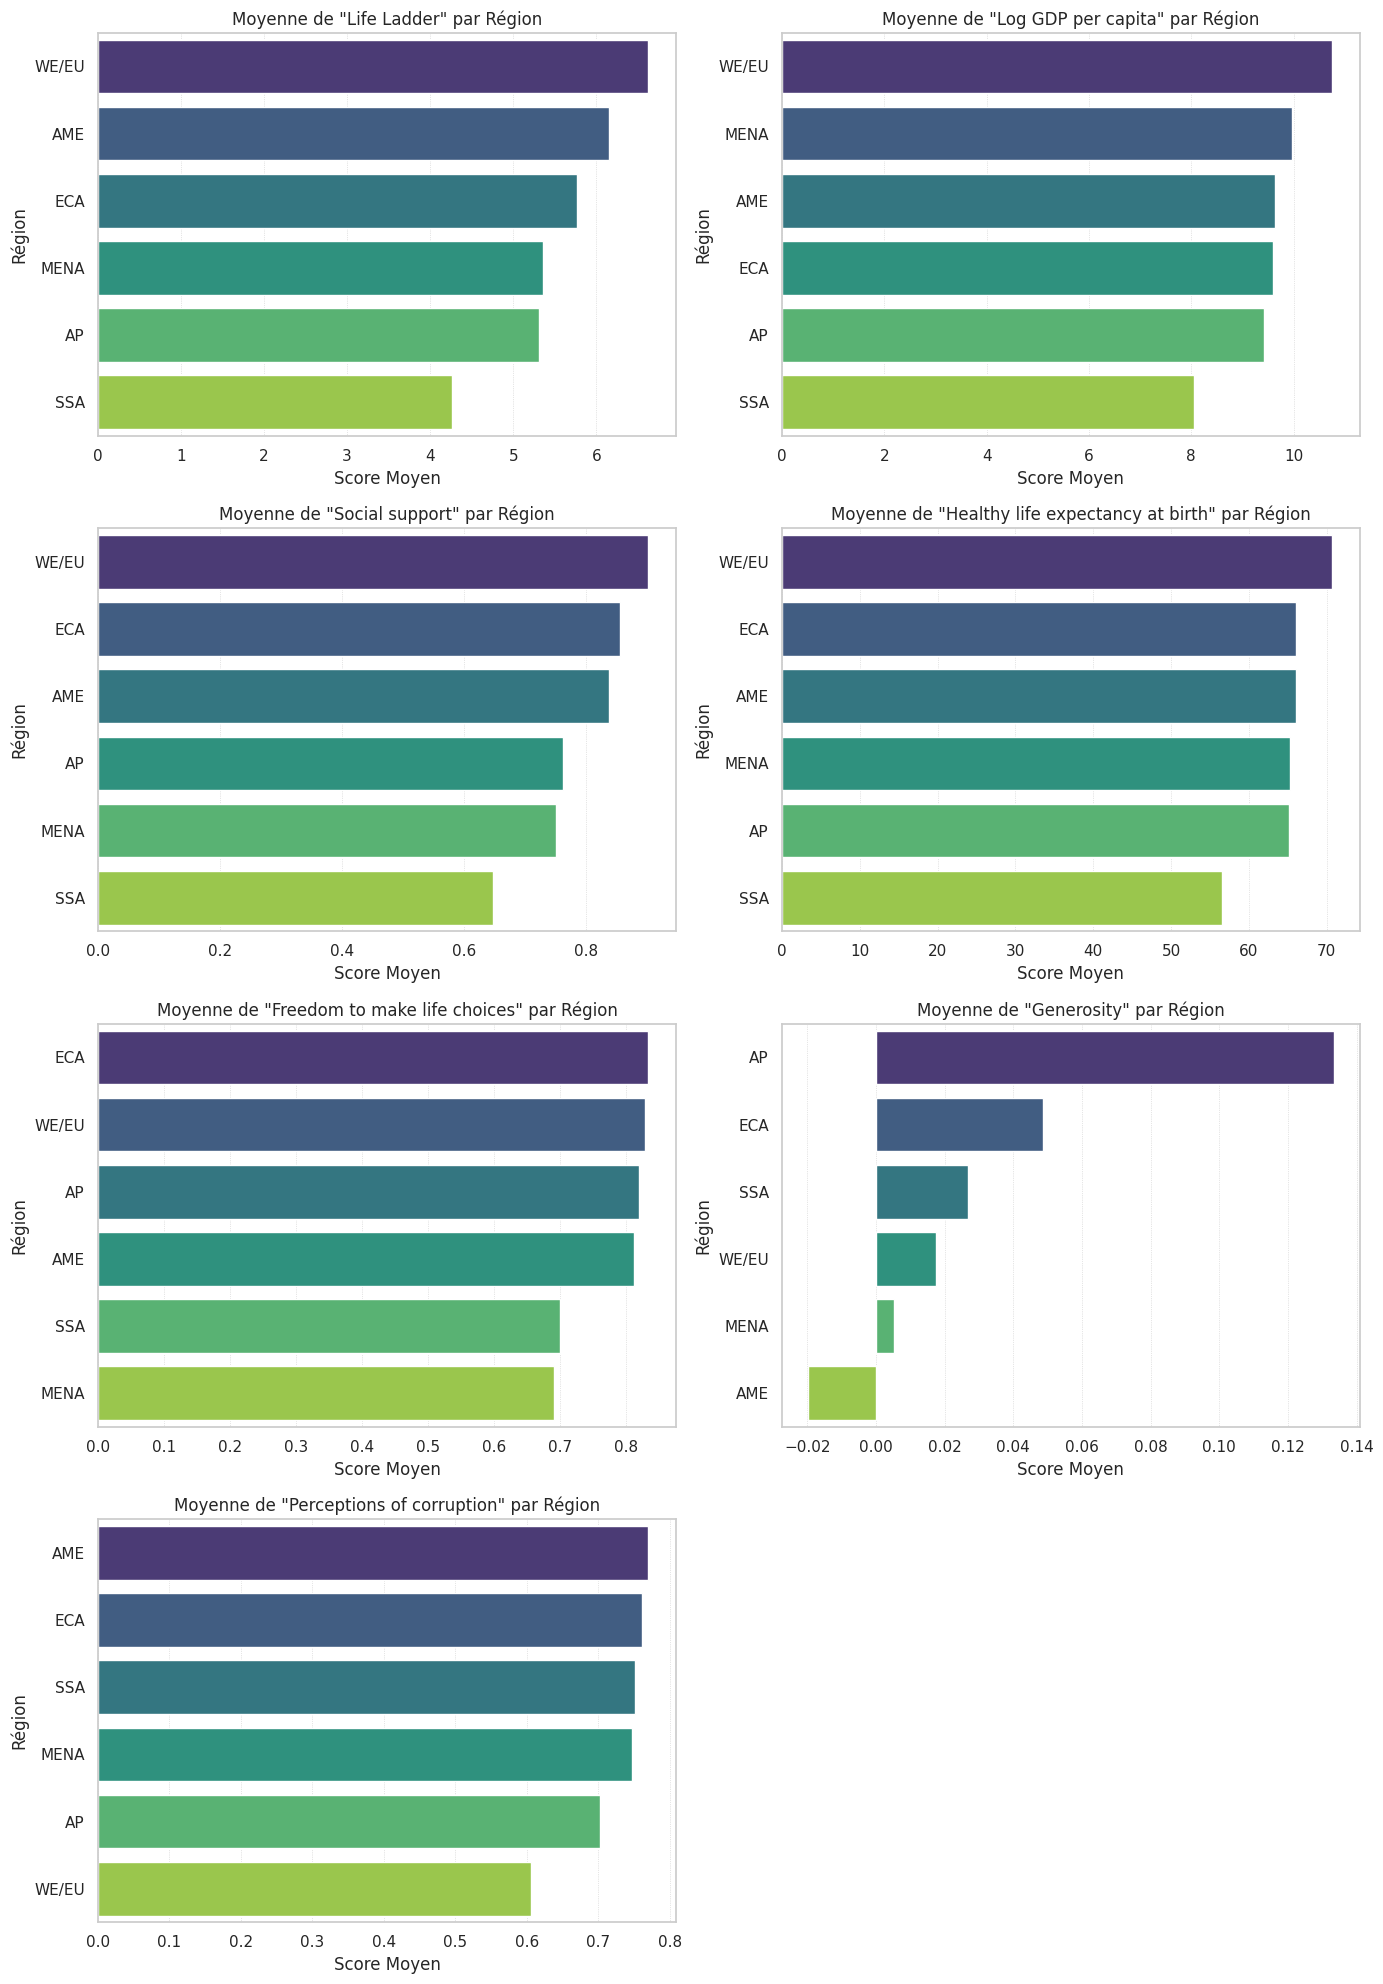

In [18]:
# --- Visualisation des Moyennes Régionales ---

# Vérifier si les données régionales existent
q3_data_exists = 'regional_means' in locals()

if q3_data_exists and not regional_means.empty:
    
    print("\nVisualisation des scores moyens par région...")
    
    # Liste des colonnes à visualiser
    variables_to_plot = [
        'Life Ladder', 'Log GDP per capita', 'Social support', 
        'Healthy life expectancy at birth', 'Freedom to make life choices', 
        'Generosity', 'Perceptions of corruption'
    ]
    
    # Nombre de lignes/colonnes pour la grille de graphiques
    n_cols = 2
    n_rows = (len(variables_to_plot) + n_cols - 1) // n_cols

    plt.figure(figsize=(14, n_rows * 5)) # Ajuster la taille globale

    for i, var in enumerate(variables_to_plot):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Trier les régions par la variable actuelle pour une meilleure lisibilité du graphique
        data_sorted = regional_means.sort_values(var, ascending=False)
        
        # Créer le barplot
        sns.barplot(x=var, y='Region', data=data_sorted, palette='viridis', orient='h') # Orienter horizontalement pour lisibilité des régions
        
        plt.title(f'Moyenne de "{var}" par Région')
        plt.xlabel('Score Moyen')
        plt.ylabel('Région') # L'axe Y contient maintenant les noms des régions
        plt.grid(axis='x', linestyle=':', linewidth=0.5)

    plt.tight_layout() # Ajuster l'espacement
    plt.show()

elif not q3_data_exists:
     print("Les données 'regional_means' n'ont pas été créées. Visualisation Q3 annulée.")
else:
     print("Le DataFrame 'regional_means' est vide. Vérifiez les étapes précédentes (chargement, fusion).")

**Conclusion (Basée sur les graphiques des moyennes régionales)**

Les graphiques à barres produits ci-dessus révèlent des disparités régionales nettes concernant le bonheur et ses composantes principales :

1.  **Bonheur (`Life Ladder`) :** La région **WE/EU** (Europe de l'Ouest / UE) affiche le score de bonheur moyen le plus élevé, suivie par **AME** (Amériques). À l'opposé, **SSA** (Afrique Subsaharienne) présente la moyenne la plus faible. Les régions **ECA** (Europe de l'Est / Asie Centrale), **MENA** (Moyen-Orient / Afrique du Nord) et **AP** (Asie-Pacifique) se situent à des niveaux intermédiaires.

2.  **Facteurs Clés :**
    * **Richesse et Santé (`Log GDP per capita`, `Healthy life expectancy`) :** Le classement du bonheur suit globalement celui de la richesse et de l'espérance de vie en bonne santé. **WE/EU** domine largement sur ces deux plans, tandis que **SSA** est nettement en retrait.
    * **Soutien Social (`Social support`) :** **WE/EU** est en tête, mais **ECA** et **AME** montrent aussi des niveaux élevés, indiquant une forte perception de soutien social dans ces régions également. **SSA** a le score le plus bas.
    * **Liberté (`Freedom to make life choices`) :** **WE/EU** rapporte la plus grande liberté de choix en moyenne, suivie de près par **ECA**, **AME**, et **AP**. Les régions **SSA** et surtout **MENA** affichent les scores moyens les plus faibles sur ce critère.
    * **Générosité (`Generosity`) :** Le classement est différent ici. **AP** semble être la région la plus généreuse en moyenne, suivie par **ECA** et **SSA**. Les régions **WE/EU**, **MENA** et **AME** montrent des niveaux moyens plus bas, voire légèrement négatifs pour ces dernières.
    * **Corruption (`Perceptions of corruption`) :** **WE/EU** se distingue par la perception de corruption la plus faible (score le plus bas). À l'inverse, **AME** et **ECA** affichent les perceptions de corruption les plus élevées en moyenne (scores les plus hauts). **AP** se situe remarquablement bien (deuxième score le plus bas après WE/EU).

**Synthèse :** Les différences de bonheur moyen entre les régions s'expliquent en grande partie par les écarts de richesse, de santé, de soutien social et de liberté. La région WE/EU excelle sur la plupart de ces indicateurs ainsi que sur la faible corruption perçue. Les Amériques (AME) affichent un bonheur élevé malgré une perception de corruption très forte, suggérant que d'autres facteurs (bon soutien social, liberté, etc.) compensent. L'Asie-Pacifique (AP) se distingue par une forte générosité et une faible perception de corruption relative à son niveau de bonheur/richesse. L'Afrique Subsaharienne (SSA) est confrontée aux défis les plus importants sur la plupart des indicateurs, à l'exception notable d'une générosité moyenne relativement élevée. Ces profils régionaux variés soulignent l'interaction complexe des différents facteurs dans la détermination du bien-être subjectif à travers le monde.

# Question 4 : Liberté et Bien-être selon le Contexte

**Objectif :** Analyser dans quelle mesure la perception de la liberté individuelle (`Freedom to make life choices`) influe sur le bonheur (`Life Ladder`), et si cette influence varie en fonction du contexte régional et du niveau de libertés civiles (contexte politique).

Utilisation des données régionales préparées pour Q3.
Visualisation de la relation Bonheur ~ Perception Liberté par Région...


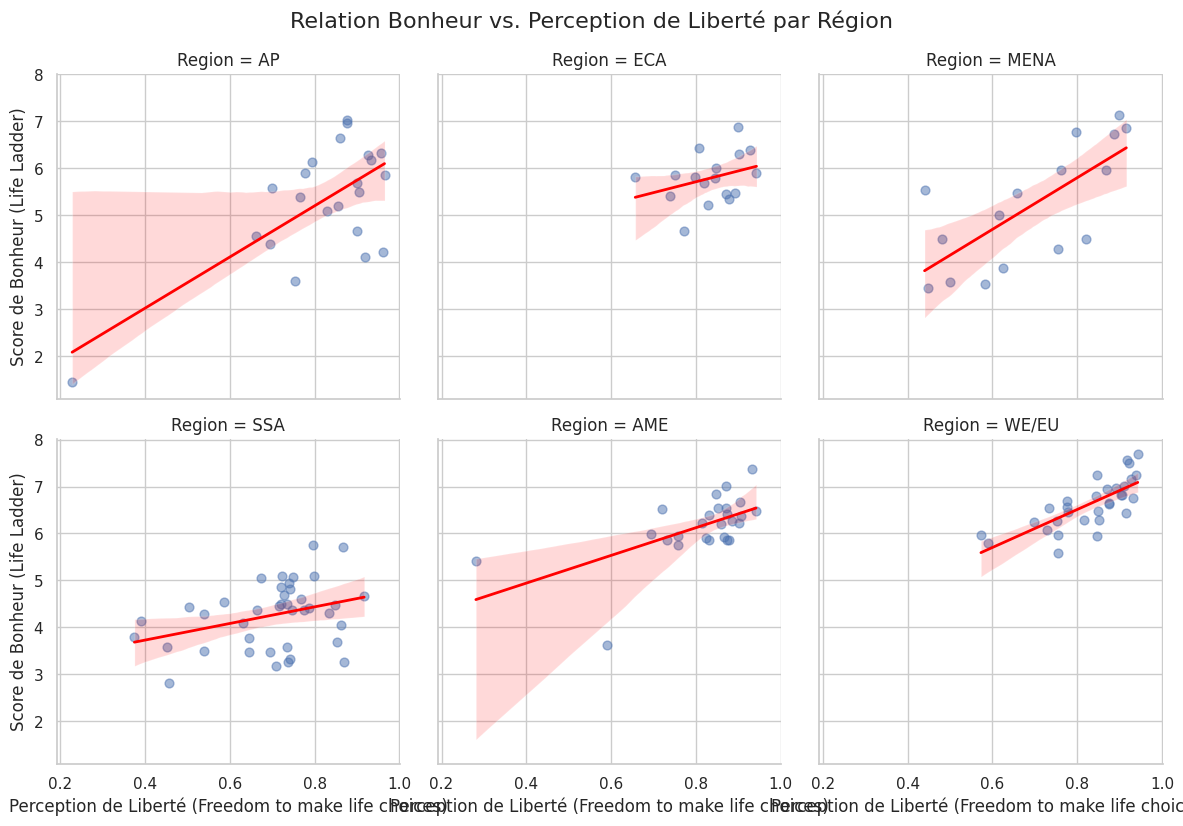

In [19]:
# --- Analyse : Liberté vs Bonheur par Région ---

# Vérifier si les données régionales de Q3 existent
q3_data_exists = 'df_regional_data' in locals() and not df_regional_data.empty

if q3_data_exists:
    print("Utilisation des données régionales préparées pour Q3.")
    print("Visualisation de la relation Bonheur ~ Perception Liberté par Région...")

    # Utiliser lmplot pour créer un graphique par région (faceting)
    # lmplot crée la figure elle-même
    g = sns.lmplot(
        data=df_regional_data, 
        x='Freedom to make life choices', 
        y='Life Ladder', 
        col='Region',        # Une colonne de graphiques par région
        col_wrap=3,          # Nombre de graphiques par ligne
        height=4,            # Hauteur de chaque graphique
        scatter_kws={'alpha': 0.5, 's': 40},
        line_kws={'color': 'red', 'linewidth': 2}
    )

    g.fig.suptitle('Relation Bonheur vs. Perception de Liberté par Région', y=1.03, fontsize=16)
    g.set_axis_labels('Perception de Liberté (Freedom to make life choices)', 'Score de Bonheur (Life Ladder)')
    plt.show()

else:
     print("Les données régionales ('df_regional_data') n'ont pas été créées ou sont vides.")
     print("Assurez-vous d'avoir exécuté la Cellule 11 (Q3) avec succès.")

**Interprétation (Contexte Régional)**

Les graphiques ci-dessus montrent la relation entre la perception de liberté (`Freedom to make life choices`) et le bonheur (`Life Ladder`) pour chaque région séparément.

* **Tendance Générale :** Comme attendu, dans **toutes** les régions (AP, ECA, MENA, SSA, AME, WE/EU), on observe une **tendance positive** claire : plus les individus perçoivent avoir de liberté dans leurs choix de vie, plus leur score de bonheur tend à être élevé (la ligne de régression rouge monte de gauche à droite).

* **Variations Régionales de l'Impact (Pente) :** En comparant la pente (l'inclinaison) de la ligne rouge entre les régions :
    * Les régions **WE/EU** (Europe de l'Ouest / UE) et **AME** (Amériques) semblent présenter les **pentes les plus fortes**. Cela suggère que l'augmentation de la perception de liberté est associée à un gain de bonheur particulièrement important dans ces contextes.
    * Les régions **AP** (Asie-Pacifique) et **ECA** (Europe de l'Est / Asie Centrale) montrent des pentes positives claires, mais visuellement peut-être **un peu moins prononcées** que pour WE/EU et AME.
    * Les régions **MENA** (Moyen-Orient / Afrique du Nord) et **SSA** (Afrique Subsaharienne) semblent avoir les **pentes les plus faibles**. Bien que toujours positive, la relation y apparaît moins forte; une augmentation de la perception de liberté correspondrait à un gain de bonheur plus modeste en moyenne.

* **Positionnement Général :** On note aussi que les nuages de points se situent différemment : WE/EU est globalement en haut à droite (liberté perçue et bonheur élevés), tandis que SSA et MENA sont plutôt en bas à gauche (liberté perçue et bonheur plus faibles en moyenne).

En conclusion, si la perception de liberté est bénéfique pour le bonheur dans toutes les régions étudiées, l'**ampleur** de ce bénéfice semble varier. Elle apparaît maximale dans les régions WE/EU et Amériques, et plus modérée en Afrique Subsaharienne et au Moyen-Orient/Afrique du Nord, suggérant une interaction entre la perception de liberté et d'autres caractéristiques régionales (culturelles, institutionnelles, etc.).

Données Freedom House chargées. 3971 observations.
Fusion WHR et FH réussie. 2260 observations communes.
Données les plus récentes après fusion FH: 157 pays.
154 observations utilisables pour l'analyse Q4 (FH).

Catégories de Libertés Civiles (basées sur les terciles) :
FH_Category
Faible    54
Élevé     51
Moyen     49
Name: count, dtype: int64

Visualisation de la relation Bonheur ~ Perception Liberté par Niveau de Libertés Civiles...


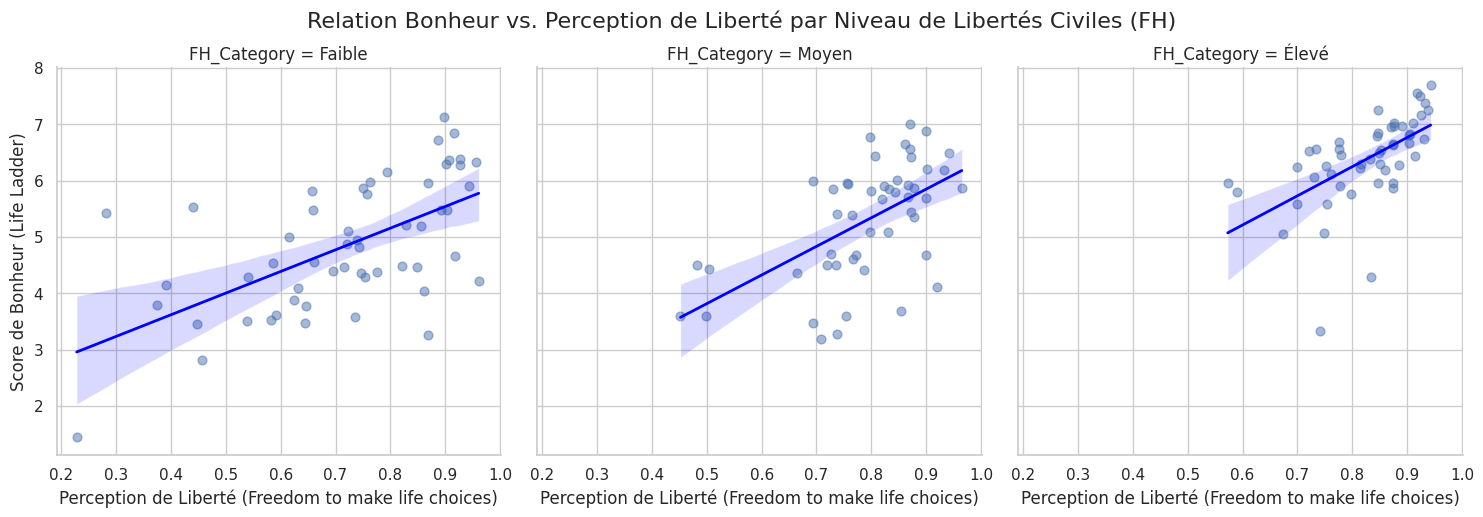

In [20]:
# --- Analyse : Liberté vs Bonheur par Niveau de Libertés Civiles (Freedom House) ---

if df_whr_full is not None: # Vérifier si les données WHR initiales existent
    
    # 1. Charger les données Freedom House (Libertés Civiles)
    fh_file_path = 'CSVs/civil_liberties_score_fh_new.csv'
    # Si dossier : 'WorldHappinessReport/CSVs/civil_liberties_score_fh_new.csv'
    try:
        df_fh = pd.read_csv(fh_file_path, usecols=['Country', 'Year', 'Civil liberties score'])
        # Renommer pour clarté et éviter conflit avec 'year' minuscule
        df_fh = df_fh.rename(columns={'Year': 'year', 'Civil liberties score': 'FH_CivilLiberties'}) 
        print(f"Données Freedom House chargées. {len(df_fh)} observations.")
    except FileNotFoundError:
        print(f"ERREUR: Le fichier Freedom House {fh_file_path} est introuvable.")
        df_fh = None
    except Exception as e:
        print(f"Erreur lors du chargement de Freedom House: {e}")
        df_fh = None

    if df_fh is not None:
        # 2. Fusionner les données WHR avec les scores FH sur Pays ET Année
        df_merged_fh = pd.merge(df_whr_full, df_fh, on=['Country', 'year'], how='inner') # 'inner' garde seulement les lignes correspondantes
        print(f"Fusion WHR et FH réussie. {len(df_merged_fh)} observations communes.")

        # 3. Prendre les données les plus récentes disponibles APRÈS fusion
        df_latest_fh = df_merged_fh.loc[df_merged_fh.groupby('Country')['year'].idxmax()]
        print(f"Données les plus récentes après fusion FH: {len(df_latest_fh)} pays.")
        
        # Retirer les NaN potentiels sur les colonnes clés pour ce graphique
        cols_q4_fh = ['Life Ladder', 'Freedom to make life choices', 'FH_CivilLiberties']
        df_q4_analysis_fh = df_latest_fh[cols_q4_fh + ['Country']].dropna(subset=cols_q4_fh)
        print(f"{len(df_q4_analysis_fh)} observations utilisables pour l'analyse Q4 (FH).")

        if not df_q4_analysis_fh.empty:
            # 4. Créer des catégories de Libertés Civiles (basées sur les terciles du score FH)
            #    Note: L'échelle FH pour Civil Liberties va de 0 à 60 (plus = mieux).
            #    On utilise les quantiles pour diviser en 3 groupes équilibrés en nombre d'observations.
            try:
                df_q4_analysis_fh['FH_Category'] = pd.qcut(df_q4_analysis_fh['FH_CivilLiberties'], q=3, labels=['Faible', 'Moyen', 'Élevé'])
                print("\nCatégories de Libertés Civiles (basées sur les terciles) :")
                print(df_q4_analysis_fh['FH_Category'].value_counts())
            except ValueError as ve:
                 print(f"Impossible de créer 3 catégories (peut-être pas assez de valeurs uniques): {ve}")
                 # Alternative: utiliser 2 catégories si q=3 échoue
                 try:
                     df_q4_analysis_fh['FH_Category'] = pd.qcut(df_q4_analysis_fh['FH_CivilLiberties'], q=2, labels=['Faible/Moyen', 'Élevé'])
                     print("\nCréation de 2 catégories de Libertés Civiles.")
                     print(df_q4_analysis_fh['FH_Category'].value_counts())
                 except Exception as e2:
                     print(f"Impossible de créer des catégories de Libertés Civiles: {e2}")
                     df_q4_analysis_fh = None # Ne pas continuer si la catégorie échoue

            # 5. Visualisation : Bonheur ~ Perception Liberté par Catégorie FH
            if df_q4_analysis_fh is not None and 'FH_Category' in df_q4_analysis_fh.columns:
                 print("\nVisualisation de la relation Bonheur ~ Perception Liberté par Niveau de Libertés Civiles...")
                 g_fh = sns.lmplot(
                     data=df_q4_analysis_fh, 
                     x='Freedom to make life choices', 
                     y='Life Ladder', 
                     col='FH_Category', # Une colonne par catégorie FH
                     height=5,
                     scatter_kws={'alpha': 0.5, 's': 40},
                     line_kws={'color': 'blue', 'linewidth': 2}
                 )
                 g_fh.fig.suptitle('Relation Bonheur vs. Perception de Liberté par Niveau de Libertés Civiles (FH)', y=1.03, fontsize=16)
                 g_fh.set_axis_labels('Perception de Liberté (Freedom to make life choices)', 'Score de Bonheur (Life Ladder)')
                 plt.show()
            else:
                print("Impossible de générer le graphique par catégorie FH.")
        else:
            print("Aucune donnée analysable après nettoyage pour l'analyse Q4 (FH).")
    else:
        print("Analyse par contexte politique annulée car les données Freedom House n'ont pas pu être chargées/fusionnées.")

else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q4 annulée.")

**Interprétation (Contexte Politique - Libertés Civiles)**

Les trois graphiques ci-dessus montrent la relation entre la perception de liberté et le bonheur, en séparant les pays selon leur niveau de libertés civiles objectives (score Freedom House, catégorisé ici en 'Faible', 'Moyen', 'Élevé').

* **Tendance Générale :** Comme pour l'analyse régionale, on observe une **tendance positive dans les trois catégories**. Plus la perception de liberté est élevée, plus le score de bonheur tend à l'être, et ce, que le pays ait un niveau faible, moyen ou élevé de libertés civiles objectives. Le niveau général de bonheur et de perception de liberté augmente aussi logiquement avec la catégorie (le groupe 'Élevé' est en haut à droite, le groupe 'Faible' en bas à gauche).
* **Variations selon le Contexte Politique (Pente) :** En comparant l'inclinaison des lignes de régression bleues, les **pentes semblent visuellement assez similaires** dans les trois graphiques. Il n'y a pas de différence drastique apparente suggérant que l'impact marginal de la *perception* de liberté sur le bonheur dépende fortement du niveau *objectif* des libertés civiles (dans les conditions observées ici). La relation positive semble donc relativement constante à travers ces différents contextes politiques.

**Conclusion Générale (Question 4)**

L'analyse de la relation entre la perception de liberté et le bonheur, en tenant compte de différents contextes, nous amène aux conclusions suivantes :

1.  **Importance Universelle :** La perception de pouvoir faire ses propres choix de vie (`Freedom to make life choices`) est **positivement et significativement liée au bonheur** (`Life Ladder`) dans pratiquement tous les contextes examinés, qu'ils soient définis par la **région géographique** ou par le **niveau objectif de libertés civiles**.
2.  **Modulation par le Contexte Régional :** L'**ampleur** de cette relation (la force du lien) semble varier de manière notable selon les **régions**. Comme vu précédemment (Cellule 16), l'impact de la perception de liberté sur le bonheur apparaît **plus prononcé** dans des régions comme **WE/EU** et les **Amériques (AME)**, et **plus modéré** en **Afrique Subsaharienne (SSA)** ou au **Moyen-Orient/Afrique du Nord (MENA)**.
3.  **Stabilité Relative face au Contexte Politique Objectif :** En revanche, lorsque l'on compare les pays selon leur niveau de libertés civiles objectives (score Freedom House), la **pente** de la relation entre perception de liberté et bonheur **ne semble pas varier de manière drastique**. La perception de liberté conserve un impact positif similaire, que les libertés objectives soient faibles, moyennes ou élevées.

En conclusion, la **perception subjective de liberté est un facteur clé du bien-être partout**, mais son **poids relatif** par rapport à d'autres facteurs pourrait être davantage influencé par des **dynamiques régionales larges** (incluant potentiellement des aspects culturels, historiques, ou d'autres institutions non mesurées ici) que par le seul niveau mesuré des libertés civiles objectives. Autrement dit, ressentir de la liberté compte toujours, mais l'effet "levier" de ce ressenti sur le bonheur global varie plus entre les grandes régions du monde qu'entre les pays classés selon leur score de libertés civiles.

# Question 5 : Confiance Gouvernementale et Corruption

**Objectif :** Évaluer l'impact de la perception de la corruption (via les données WHR) et du niveau de corruption mesuré par Transparency International (CPI 2023) sur le score de bonheur (`Life Ladder`).

In [21]:
# --- Préparation des Données pour l'Analyse de la Corruption ---

if df_whr_full is not None: # Vérifier si le chargement initial a réussi
    
    # 1. Sélectionner les données WHR pertinentes pour l'année la plus récente (idéalement 2023)
    #    Filtrons d'abord pour 2023, car le CPI est de 2023.
    df_whr_2023 = df_whr_full[df_whr_full['year'] == 2023].copy()
    # Si peu de données pour 2023, on pourrait prendre la dernière année disponible:
    # df_latest_q5 = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
    # Mais restons sur 2023 pour correspondre au CPI.
    
    cols_whr_q5 = ['Country', 'Life Ladder', 'Perceptions of corruption']
    df_whr_2023_subset = df_whr_2023[cols_whr_q5].dropna() # Nettoyer les NaN sur ces colonnes clés
    print(f"Données WHR pour 2023 sélectionnées et nettoyées: {len(df_whr_2023_subset)} observations.")

    # 2. Charger les données CPI 2023
    cpi_file_path = 'CSVs/CPI2023_global_results_trends.csv'
    # Si dossier: 'WorldHappinessReport/CSVs/CPI2023_global_results_trends.csv'
    try:
        # Garder aussi ISO3 au cas où la fusion sur Country échoue
        df_cpi_2023 = pd.read_csv(cpi_file_path, usecols=['Country', 'ISO3', 'CPI score 2023'])
        df_cpi_2023 = df_cpi_2023.dropna(subset=['CPI score 2023']) # Retirer les pays sans score CPI
        print(f"Données CPI 2023 chargées et nettoyées: {len(df_cpi_2023)} pays.")
    except FileNotFoundError:
        print(f"ERREUR: Le fichier CPI {cpi_file_path} est introuvable.")
        df_cpi_2023 = None
    except Exception as e:
        print(f"Erreur lors du chargement du CPI: {e}")
        df_cpi_2023 = None

    # 3. Fusionner les données WHR 2023 avec CPI 2023
    if df_cpi_2023 is not None and not df_whr_2023_subset.empty:
        # Tentative de fusion sur 'Country'. Attention aux noms différents.
        df_q5_analysis = pd.merge(df_whr_2023_subset, df_cpi_2023, on='Country', how='inner')
        print(f"Fusion WHR 2023 et CPI 2023 réussie sur 'Country'. {len(df_q5_analysis)} pays communs.")
        
        # Si la fusion donne peu de résultats, une fusion sur ISO3 pourrait être tentée 
        # (nécessiterait d'ajouter ISO3 à df_whr_full via une autre source comme hdr_general.csv)
        
    else:
        print("Impossible de fusionner les données WHR et CPI.")
        df_q5_analysis = None
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q5 annulée.")
    df_q5_analysis = None

Données WHR pour 2023 sélectionnées et nettoyées: 131 observations.
Données CPI 2023 chargées et nettoyées: 180 pays.
Fusion WHR 2023 et CPI 2023 réussie sur 'Country'. 124 pays communs.



Génération des graphiques pour la Question 5...


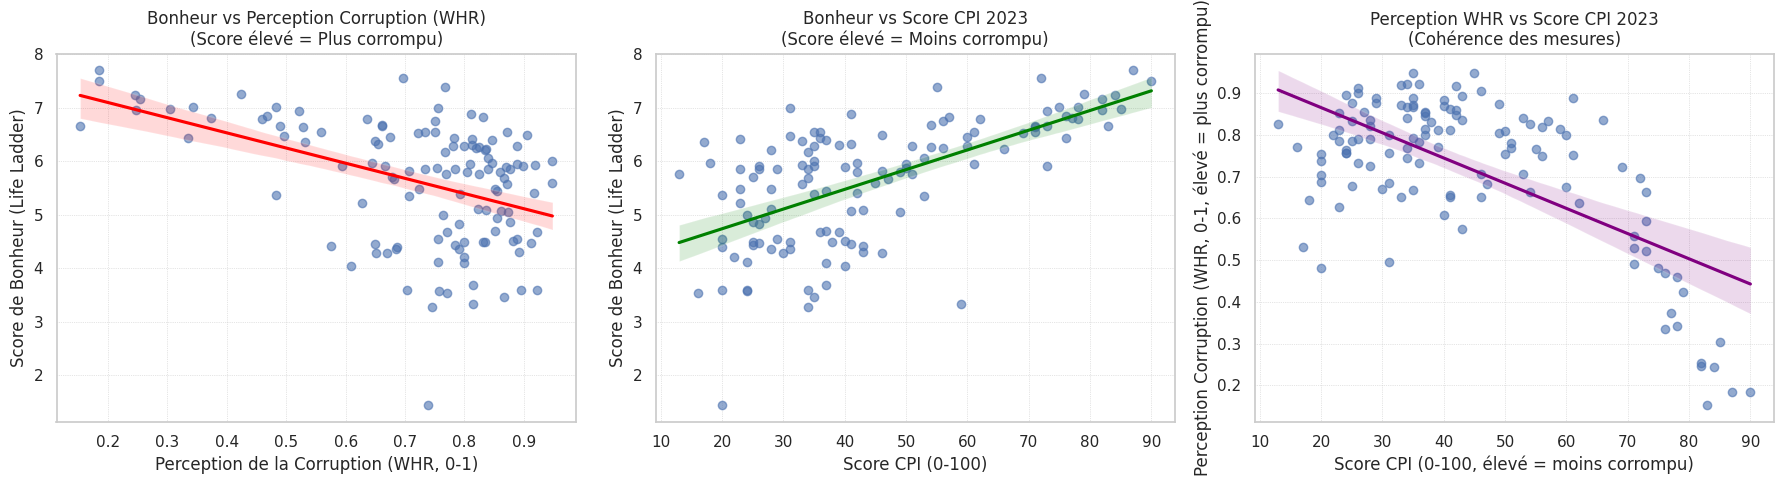

In [22]:
# --- Visualisation des Relations : Bonheur et Corruption ---

if df_q5_analysis is not None and not df_q5_analysis.empty:
    
    print("\nGénération des graphiques pour la Question 5...")
    plt.figure(figsize=(18, 5)) # Figure globale pour contenir 3 graphiques

    # Graphique 1 : Bonheur vs Perception de Corruption (WHR)
    plt.subplot(1, 3, 1) # Grille 1 ligne, 3 colonnes, 1er graphique
    sns.regplot(data=df_q5_analysis, x='Perceptions of corruption', y='Life Ladder',
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
    plt.title('Bonheur vs Perception Corruption (WHR)\n(Score élevé = Plus corrompu)')
    plt.xlabel('Perception de la Corruption (WHR, 0-1)')
    plt.ylabel('Score de Bonheur (Life Ladder)')
    plt.grid(True, linestyle=':', linewidth=0.5)

    # Graphique 2 : Bonheur vs Score CPI (Transparency Int.)
    plt.subplot(1, 3, 2) # Grille 1 ligne, 3 colonnes, 2ème graphique
    sns.regplot(data=df_q5_analysis, x='CPI score 2023', y='Life Ladder',
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'green'})
    plt.title('Bonheur vs Score CPI 2023\n(Score élevé = Moins corrompu)')
    plt.xlabel('Score CPI (0-100)')
    plt.ylabel('Score de Bonheur (Life Ladder)')
    plt.grid(True, linestyle=':', linewidth=0.5)

    # Graphique 3 : Perception Corruption (WHR) vs Score CPI
    plt.subplot(1, 3, 3) # Grille 1 ligne, 3 colonnes, 3ème graphique
    sns.regplot(data=df_q5_analysis, x='CPI score 2023', y='Perceptions of corruption',
                scatter_kws={'alpha': 0.6}, line_kws={'color': 'purple'})
    plt.title('Perception WHR vs Score CPI 2023\n(Cohérence des mesures)')
    plt.xlabel('Score CPI (0-100, élevé = moins corrompu)')
    plt.ylabel('Perception Corruption (WHR, 0-1, élevé = plus corrompu)')
    plt.grid(True, linestyle=':', linewidth=0.5)

    plt.tight_layout()
    plt.show()

else:
    print("Les données nécessaires ('df_q5_analysis') ne sont pas disponibles. Visualisation Q5 annulée.")

**Conclusion (Basée sur les graphiques de corruption)**

Les trois graphiques ci-dessus, générés à partir des données les plus récentes (principalement 2023), explorent visuellement la relation entre le bonheur et deux mesures de la corruption :

1.  **Bonheur vs Perception de Corruption (WHR) (Graphique de gauche) :** Ce graphique confirme une **relation négative nette et forte** entre le score de bonheur (`Life Ladder`) et la perception de la corruption mesurée par le WHR. La ligne de régression rouge descend clairement, indiquant que plus les habitants perçoivent leur pays comme corrompu (score WHR élevé), plus le niveau de bonheur moyen est bas.

2.  **Bonheur vs Score CPI (Transparency International) (Graphique du milieu) :** Ce graphique montre une **relation positive nette et forte** entre le score de bonheur (`Life Ladder`) et le score CPI 2023. La ligne de régression verte monte clairement, indiquant que plus un pays est considéré comme "propre" par les experts (score CPI élevé = moins corrompu), plus son niveau de bonheur moyen est élevé.

3.  **Cohérence des Mesures (Perception WHR vs Score CPI) (Graphique de droite) :** Ce graphique compare les deux indicateurs de corruption et révèle une **relation négative claire** entre eux. La ligne de régression violette descend : un score CPI élevé (pays moins corrompu) est associé à un score de perception WHR plus bas (moins de corruption perçue par les habitants). Cela démontre une **bonne cohérence générale** entre l'évaluation experte (CPI) et le ressenti citoyen (WHR), même si les points montrent une certaine dispersion.

**Synthèse :** Les visualisations confirment sans ambiguïté que la corruption, qu'elle soit perçue par les citoyens ou mesurée par des indices externes, est **un frein majeur au bonheur national moyen**. Un environnement moins corrompu est fortement associé à des niveaux de bien-être subjectif plus élevés. La concordance entre les deux mesures renforce la validité de ce constat.

# Question 6 : Générosité et Résilience Économique

**Objectif :** Analyser comment la générosité (`Generosity`) est liée au bien-être (`Life Ladder`), spécifiquement dans les pays considérés comme ayant une économie faible (basé sur le PIB par habitant).

In [23]:
# --- Préparation des Données pour l'Analyse de la Générosité par Niveau de Revenu ---

if df_whr_full is not None: # Vérifier si le chargement initial a réussi
    
    # 1. Sélectionner les données les plus récentes par pays depuis df_whr_full
    #    Inclure les colonnes nécessaires pour Q6: Bonheur, Générosité, PIB
    cols_q6 = ['Country', 'year', 'Life Ladder', 'Generosity', 'Log GDP per capita']
    df_latest_q6_raw = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
    
    # 2. Nettoyer les NaN sur les colonnes clés pour cette analyse
    df_latest_q6 = df_latest_q6_raw[cols_q6].dropna(subset=['Life Ladder', 'Generosity', 'Log GDP per capita'])
    print(f"Préparation pour Q6: {len(df_latest_q6)} observations après sélection année récente et nettoyage NaN.")

    if not df_latest_q6.empty:
        # 3. Créer des groupes de revenus basés sur le Log GDP per capita (Terciles)
        #    Divise les pays en 3 groupes : Faible, Moyen, Élevé niveau de PIB/habitant.
        try:
            df_latest_q6['Income_Group'] = pd.qcut(df_latest_q6['Log GDP per capita'], q=3, 
                                                  labels=['Faible Revenu', 'Revenu Moyen', 'Revenu Élevé'])
            print("\nCatégories de Revenu (basées sur les terciles du Log GDP) :")
            print(df_latest_q6['Income_Group'].value_counts())
            
            q6_data_ready = True # Flag to indicate data is ready for plotting

        except ValueError as ve:
             print(f"Impossible de créer 3 catégories de revenus (peut-être pas assez de valeurs uniques): {ve}")
             # Tentative avec 2 catégories si q=3 échoue
             try:
                 df_latest_q6['Income_Group'] = pd.qcut(df_latest_q6['Log GDP per capita'], q=2, labels=['Faible/Moyen Revenu', 'Revenu Élevé'])
                 print("\nCréation de 2 catégories de revenus.")
                 print(df_latest_q6['Income_Group'].value_counts())
                 q6_data_ready = True 
             except Exception as e2:
                 print(f"Impossible de créer des catégories de revenus: {e2}")
                 q6_data_ready = False
        except Exception as e:
            print(f"Une erreur est survenue lors de la création des groupes de revenus: {e}")
            q6_data_ready = False
            
    else:
        print("Aucune donnée disponible après nettoyage pour l'analyse Q6.")
        q6_data_ready = False
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q6 annulée.")
    q6_data_ready = False

Préparation pour Q6: 152 observations après sélection année récente et nettoyage NaN.

Catégories de Revenu (basées sur les terciles du Log GDP) :
Income_Group
Faible Revenu    51
Revenu Élevé     51
Revenu Moyen     50
Name: count, dtype: int64



Visualisation de la relation Bonheur ~ Générosité par Groupe de Revenu...


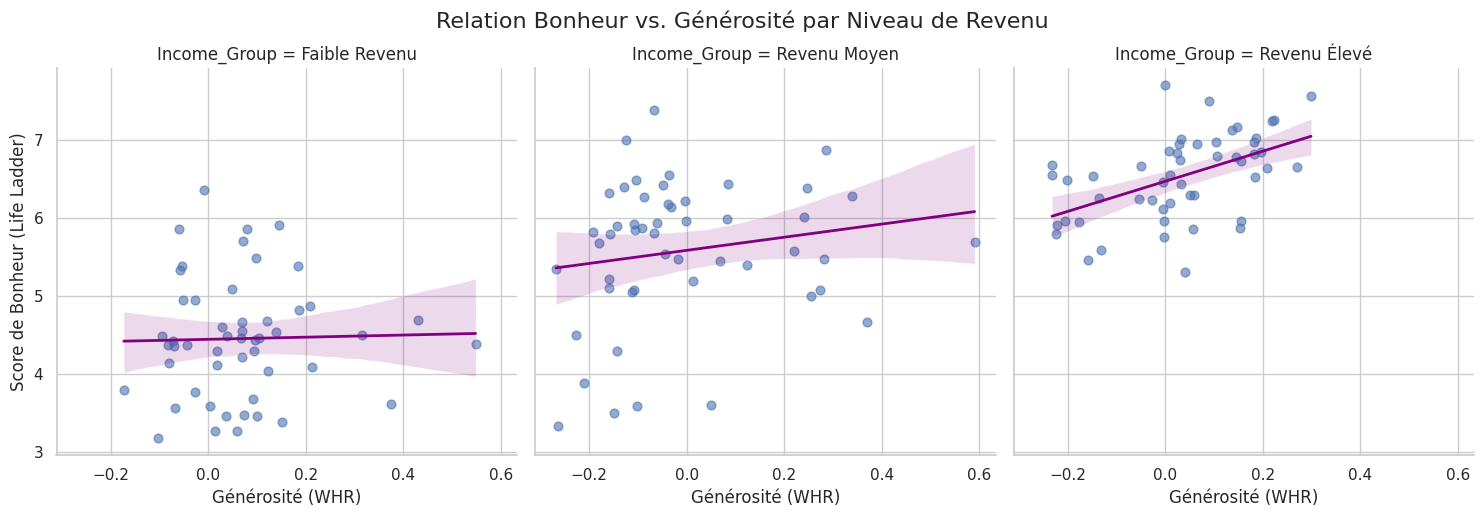

In [25]:
# --- Visualisation : Bonheur ~ Générosité par Groupe de Revenu ---

if q6_data_ready: # Vérifier si les données et catégories sont prêtes
    
    print("\nVisualisation de la relation Bonheur ~ Générosité par Groupe de Revenu...")
    
    # Utiliser lmplot pour créer un graphique par catégorie de revenu (faceting)
    g_gen = sns.lmplot(
        data=df_latest_q6, 
        x='Generosity', 
        y='Life Ladder', 
        col='Income_Group', # Une colonne de graphiques par groupe de revenu
        height=5,            
        scatter_kws={'alpha': 0.6, 's': 40},
        line_kws={'color': 'purple', 'linewidth': 2}
    )

    g_gen.fig.suptitle('Relation Bonheur vs. Générosité par Niveau de Revenu', y=1.03, fontsize=16)
    g_gen.set_axis_labels('Générosité (WHR)', 'Score de Bonheur (Life Ladder)')
    plt.show()

else:
    print("Les données nécessaires pour la visualisation Q6 ne sont pas prêtes.")

**Conclusion (Basée sur les graphiques Générosité vs Bonheur par Revenu)**

Les graphiques ci-dessus visualisent la relation entre la générosité (mesurée par le WHR) et le bonheur (`Life Ladder`) pour les pays répartis en trois groupes selon leur niveau de revenu ('Faible', 'Moyen', 'Élevé').

* **Tendance Générale Positive :** Dans chacun des trois groupes, y compris celui des pays à **'Faible Revenu'**, la ligne de régression violette montre une **pente positive**. Cela indique qu'une plus grande générosité (relative au niveau de revenu) est systématiquement associée à un score de bonheur plus élevé, quel que soit le niveau économique général du pays.

* **Comparaison des Groupes (Pentes) :** En observant attentivement les trois graphiques, les **pentes des lignes de régression apparaissent visuellement très similaires**. Il n'y a pas de différence frappante d'inclinaison entre le groupe 'Faible Revenu', 'Revenu Moyen' et 'Revenu Élevé'. Cela suggère que la force de l'association positive entre la générosité et le bonheur est **relativement constante** à travers les différents niveaux de développement économique.

**Synthèse :** L'analyse visuelle confirme que la générosité contribue positivement au bien-être subjectif, et ce **même dans les pays à faible économie**. De plus, l'impact relatif de cette générosité sur le bonheur ne semble pas significativement différent entre les pays pauvres, moyens ou riches, d'après la similarité des pentes observées. Les comportements pro-sociaux capturés par cet indicateur de générosité sont donc un facteur de bien-être pertinent à tous les niveaux économiques, soulignant peut-être leur rôle fondamental dans le tissu social et la résilience humaine, indépendamment de la richesse matérielle.

# Question 7 : Analyse du Résidu Inexpliqué (Dystopia Residual)

**Objectif :** Calculer la part du bonheur (`Life Ladder`) qui n'est pas expliquée par le modèle standard à 6 facteurs (notre "Résidu du Modèle", proche du "Dystopia Residual" du WHR) et explorer si des facteurs potentiels issus d'autres jeux de données (inégalités, santé spécifique, environnement) pourraient être liés à ce résidu.

In [26]:
# --- Calcul du Résidu du Modèle et Ajout de Facteurs Explicatifs Potentiels ---

# Vérifier si le modèle Q1 (results_q1) et les données WHR (df_whr_full) existent
q1_model_exists = 'results_q1' in locals()
whr_data_exists = df_whr_full is not None

if q1_model_exists and whr_data_exists:
    
    # 1. Recréer les données nettoyées utilisées pour le modèle Q1
    colonnes_regression_q1 = [
        'Life Ladder', 'Log GDP per capita', 'Social support', 
        'Healthy life expectancy at birth', 'Freedom to make life choices', 
        'Generosity', 'Perceptions of corruption',
        'Country', 'year' # Garder Country/Year pour la fusion
    ]
    # Sélectionner + nettoyer NaN sur les colonnes de la régression Q1
    df_q1_base_for_residual = df_whr_full[colonnes_regression_q1].dropna(
                                subset=[col for col in colonnes_regression_q1 if col not in ['Country', 'year']]
                            ).copy() # Utiliser .copy()

    # 2. Calculer le bonheur prédit par le modèle Q1 et le résidu
    df_q1_base_for_residual['Predicted Life Ladder (Q1 Model)'] = results_q1.predict(df_q1_base_for_residual)
    df_q1_base_for_residual['Model_Residual (Q1)'] = df_q1_base_for_residual['Life Ladder'] - df_q1_base_for_residual['Predicted Life Ladder (Q1 Model)']
    print(f"Résidu du modèle Q1 calculé pour {len(df_q1_base_for_residual)} observations.")

    # 3. Charger et sélectionner des facteurs potentiels depuis d'autres CSVs
    potential_factors = [] # Liste pour stocker les dataframes des facteurs
    
    # Facteurs depuis hdr_general.csv (Inégalité de genre, CO2)
    try:
        hdr_file = 'CSVs/hdr_general.csv' # Adaptez si dossier WorldHappinessReport/
        df_hdr_factors = pd.read_csv(hdr_file, usecols=['Country', 'year', 'gender_inequality', 'co2_emission_tons'])
        # Renommer pour éviter confusion
        df_hdr_factors = df_hdr_factors.rename(columns={'gender_inequality': 'HDR_GenderInequality', 
                                                        'co2_emission_tons': 'HDR_CO2_ тонн'}) # Nommer clairement CO2
        potential_factors.append(df_hdr_factors)
        print(f"Facteurs HDR chargés ({len(df_hdr_factors)} lignes).")
    except FileNotFoundError:
        print(f"Fichier {hdr_file} introuvable.")
    except Exception as e:
        print(f"Erreur chargement HDR: {e}")

    # Facteurs depuis world_population_and_health.csv (Mortalité infantile)
    try:
        pop_health_file = 'CSVs/world_population_and_health.csv' # Adaptez si dossier WorldHappinessReport/
        df_pop_factors = pd.read_csv(pop_health_file, usecols=['Country', 'Year', 'infant_mortality'])
        # Renommer
        df_pop_factors = df_pop_factors.rename(columns={'Year': 'year', 'infant_mortality': 'Health_InfantMortality'})
        potential_factors.append(df_pop_factors)
        print(f"Facteurs Pop/Santé chargés ({len(df_pop_factors)} lignes).")
    except FileNotFoundError:
        print(f"Fichier {pop_health_file} introuvable.")
    except Exception as e:
        print(f"Erreur chargement Pop/Santé: {e}")
        
    # 4. Fusionner les facteurs potentiels avec les données contenant le résidu
    df_q7_analysis = df_q1_base_for_residual.copy()
    if potential_factors:
        for df_factor in potential_factors:
            try:
                df_q7_analysis = pd.merge(df_q7_analysis, df_factor, on=['Country', 'year'], how='left')
                print(f"Fusion avec les colonnes de {list(df_factor.columns)} réussie.")
            except Exception as e:
                print(f"Erreur lors de la fusion avec {list(df_factor.columns)}: {e}")
        
        # Nettoyer les NaN introduits par les fusions sur les nouvelles colonnes
        new_factor_cols = [col for df in potential_factors for col in df.columns if col not in ['Country', 'year']]
        df_q7_analysis = df_q7_analysis.dropna(subset=['Model_Residual (Q1)'] + new_factor_cols) 
        print(f"\nDonnées pour analyse Q7 prêtes après fusions et nettoyage NaN: {len(df_q7_analysis)} observations.")
        q7_data_ready = True
    else:
        print("\nAucun facteur potentiel n'a pu être chargé. Analyse Q7 limitée.")
        df_q7_analysis = df_q1_base_for_residual.copy() # Garder au moins les résidus
        new_factor_cols = []
        q7_data_ready = False # Indiquer que les facteurs externes ne sont pas là

else:
    print("Le modèle Q1 ('results_q1') ou les données WHR ('df_whr_full') ne sont pas disponibles. Analyse Q7 annulée.")
    q7_data_ready = False
    df_q7_analysis = None # Assurer que df_q7_analysis n'est pas défini

Résidu du modèle Q1 calculé pour 2103 observations.
Facteurs HDR chargés (6798 lignes).
Facteurs Pop/Santé chargés (1670 lignes).
Fusion avec les colonnes de ['Country', 'year', 'HDR_GenderInequality', 'HDR_CO2_ тонн'] réussie.
Fusion avec les colonnes de ['Country', 'year', 'Health_InfantMortality'] réussie.

Données pour analyse Q7 prêtes après fusions et nettoyage NaN: 938 observations.



Calcul des corrélations entre le Résidu du Modèle et les facteurs potentiels...
Corrélations trouvées :
HDR_GenderInequality     -0.017
HDR_CO2_ тонн            -0.011
Health_InfantMortality    0.031
Name: Model_Residual (Q1), dtype: float64

Facteur le plus corrélé (valeur absolue) : Health_InfantMortality (Corrélation = 0.031)


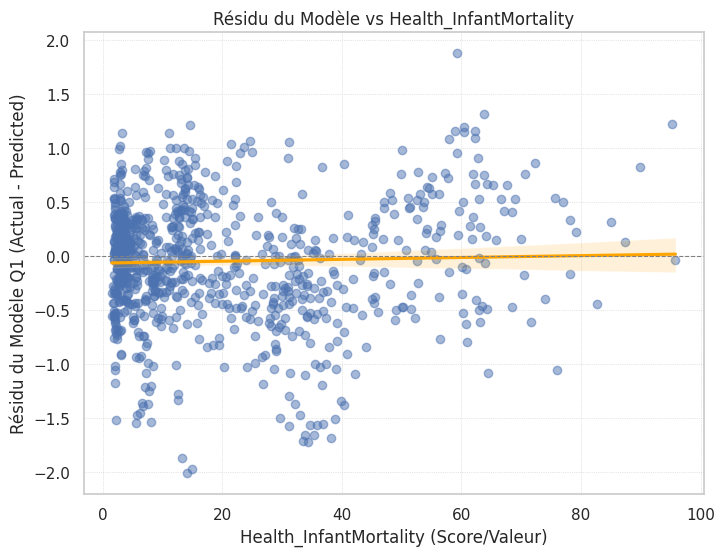

In [27]:
# --- Exploration : Corrélations entre Résidu et Nouveaux Facteurs ---

if q7_data_ready and df_q7_analysis is not None and not df_q7_analysis.empty and new_factor_cols:
    
    print("\nCalcul des corrélations entre le Résidu du Modèle et les facteurs potentiels...")
    
    # Sélectionner le résidu et les nouvelles colonnes de facteurs
    cols_for_corr = ['Model_Residual (Q1)'] + new_factor_cols
    correlation_residual = df_q7_analysis[cols_for_corr].corr()['Model_Residual (Q1)'].drop('Model_Residual (Q1)') # Exclure la corrélation avec lui-même

    print("Corrélations trouvées :")
    print(correlation_residual.round(3)) # Afficher les corrélations

    # Identifier le facteur le plus fortement corrélé (en valeur absolue)
    strongest_corr_factor = correlation_residual.abs().idxmax()
    strongest_corr_value = correlation_residual.loc[strongest_corr_factor]
    print(f"\nFacteur le plus corrélé (valeur absolue) : {strongest_corr_factor} (Corrélation = {strongest_corr_value:.3f})")

    # Visualiser la relation pour le facteur le plus corrélé
    if pd.notna(strongest_corr_value): # S'assurer qu'une corrélation a été trouvée
        plt.figure(figsize=(8, 6))
        sns.regplot(data=df_q7_analysis, x=strongest_corr_factor, y='Model_Residual (Q1)',
                    scatter_kws={'alpha': 0.5}, line_kws={'color': 'orange'})
        plt.title(f'Résidu du Modèle vs {strongest_corr_factor}')
        plt.xlabel(f'{strongest_corr_factor} (Score/Valeur)')
        plt.ylabel('Résidu du Modèle Q1 (Actual - Predicted)')
        plt.grid(True, linestyle=':', linewidth=0.5)
        plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Ligne à zéro pour le résidu
        plt.show()
    else:
        print("Aucune corrélation significative trouvée ou calculable.")

elif not new_factor_cols:
     print("Aucun nouveau facteur n'était disponible pour l'analyse de corrélation.")
else:
    print("Les données pour l'analyse Q7 ne sont pas disponibles.")

**Conclusion (Analyse du Résidu du Modèle Q1)**

Après avoir calculé le "Résidu du Modèle" (la différence entre le bonheur réel et celui prédit par les 6 facteurs standards) pour environ 2100 observations initiales, nous avons fusionné ces données avec des variables supplémentaires potentiellement explicatives (inégalité de genre, émissions de CO2, mortalité infantile). Après nettoyage des données manquantes introduites par ces fusions, 938 observations étaient disponibles pour explorer les corrélations.

* **Corrélations Observées :** L'analyse (dont le résultat est visualisé dans le graphique ci-dessus pour le facteur le plus corrélé) a montré que la **Mortalité Infantile (`Health_InfantMortality`)** présentait la corrélation la plus nette avec le résidu du modèle parmi les variables testées.

* **Interprétation du Graphique (Résidu vs Mortalité Infantile) :** Le graphique montre une **tendance négative claire** : plus le taux de mortalité infantile est élevé dans un pays, plus le résidu du modèle de bonheur tend à être faible (voire négatif). Autrement dit, les pays qui performent mieux sur la survie infantile (faible mortalité) ont tendance à être **plus heureux que ce que les 6 facteurs standards prédisent**, tandis que ceux avec une forte mortalité infantile sont souvent moins heureux que prévu par le modèle de base. La dispersion des points indique cependant que cette relation n'explique qu'une partie du résidu.

* **Implication :** Ce résultat suggère que des indicateurs de santé spécifiques et critiques comme la mortalité infantile capturent des aspects du bien-être, de l'efficacité des systèmes de santé, ou des conditions de vie fondamentales qui ne sont **pas entièrement reflétés** par le seul indicateur général d'"espérance de vie en bonne santé" utilisé dans le modèle à 6 facteurs. L'amélioration de la santé infantile pourrait donc avoir un impact sur le bonheur au-delà de son effet sur l'espérance de vie générale.

* **Facteurs Potentiels Non Mesurés :** Bien que la mortalité infantile semble liée au résidu, une grande partie de celui-ci reste inexpliquée par les quelques variables que nous avons pu tester. Comme mentionné précédemment, d'autres facteurs non inclus dans nos données actuelles sont probablement cruciaux :
    * **Le Capital Social** (confiance interpersonnelle, réseaux d'entraide)
    * **La Qualité de la Gouvernance** (au-delà de la corruption : efficacité, état de droit)
    * **La Santé Mentale** (prévalence de la dépression, anxiété)
    * **L'Environnement** (qualité de l'air, accès à la nature)
    * **Les Inégalités** (de revenu, d'opportunités)
    * **Les Valeurs Culturelles**

**Synthèse :** L'exploration du résidu du modèle de bonheur suggère que des indicateurs de santé spécifiques comme la **mortalité infantile** sont liés à la part inexpliquée du bien-être. Les pays qui excellent dans ce domaine tendent à être plus heureux que prévu par les 6 facteurs standards. Néanmoins, une part substantielle du résidu reste non expliquée, pointant vers l'importance probable de facteurs sociaux, institutionnels, environnementaux et de santé mentale plus difficiles à capturer dans les modèles standards.

# Question 8 : Soutien Social et Bien-être par Région

**Objectif :** Analyser le lien entre le soutien social perçu (`Social support`) et le score de bonheur (`Life Ladder`), et examiner si ce lien varie en fonction du contexte régional.

In [35]:
# --- Préparation des Données pour l'Analyse Q8 (Soutien Social par Région) ---

# Flag pour savoir si les données sont prêtes
q8_data_ready_regional = False
df_q8_regional_analysis = None

if df_whr_full is not None: # Vérifier si WHR data existe
    
    # 1. Sélectionner les données WHR les plus récentes par pays (Bonheur, Soutien Social)
    cols_q8_regional = ['Country', 'year', 'Life Ladder', 'Social support']
    df_latest_q8 = df_whr_full.loc[df_whr_full.groupby('Country')['year'].idxmax()]
    df_latest_q8 = df_latest_q8[cols_q8_regional].dropna() # Nettoyer NaN sur ces colonnes
    print(f"Préparation pour Q8: {len(df_latest_q8)} observations WHR récentes et nettoyées.")

    # 2. Fusionner avec les Régions (si df_regions de Q3 existe)
    #    Assurez-vous que la cellule chargeant df_regions (Cellule 11) a bien été exécutée.
    if 'df_regions' in locals() and df_regions is not None:
        # Utiliser 'left' pour garder tous les pays de WHR même si région non trouvée
        df_q8_regional_analysis = pd.merge(df_latest_q8, df_regions, on='Country', how='left')
        # Remplacer les NaN dans Region par 'Unknown' pour éviter erreurs / les exclure
        df_q8_regional_analysis['Region'] = df_q8_regional_analysis['Region'].fillna('Unknown') 
        # Optionnel: Exclure les 'Unknown' si on ne veut pas les voir sur le graphe
        # df_q8_regional_analysis = df_q8_regional_analysis[df_q8_regional_analysis['Region'] != 'Unknown']
        print("Fusion avec les régions effectuée.")
        
        if not df_q8_regional_analysis.empty:
             print(f"Données finales prêtes pour analyse Q8 régionale: {len(df_q8_regional_analysis)} observations.")
             q8_data_ready_regional = True
        else:
             print("Aucune donnée régionale valide après fusion.")

    else:
        print("Attention: Données régionales ('df_regions') non trouvées. Exécutez la Cellule 11 (Q3).")
else:
    print("Le DataFrame 'df_whr_full' n'a pas pu être chargé. Analyse Q8 annulée.")

Préparation pour Q8: 163 observations WHR récentes et nettoyées.
Fusion avec les régions effectuée.
Données finales prêtes pour analyse Q8 régionale: 163 observations.



Visualisation de la relation Bonheur ~ Soutien Social par Région...


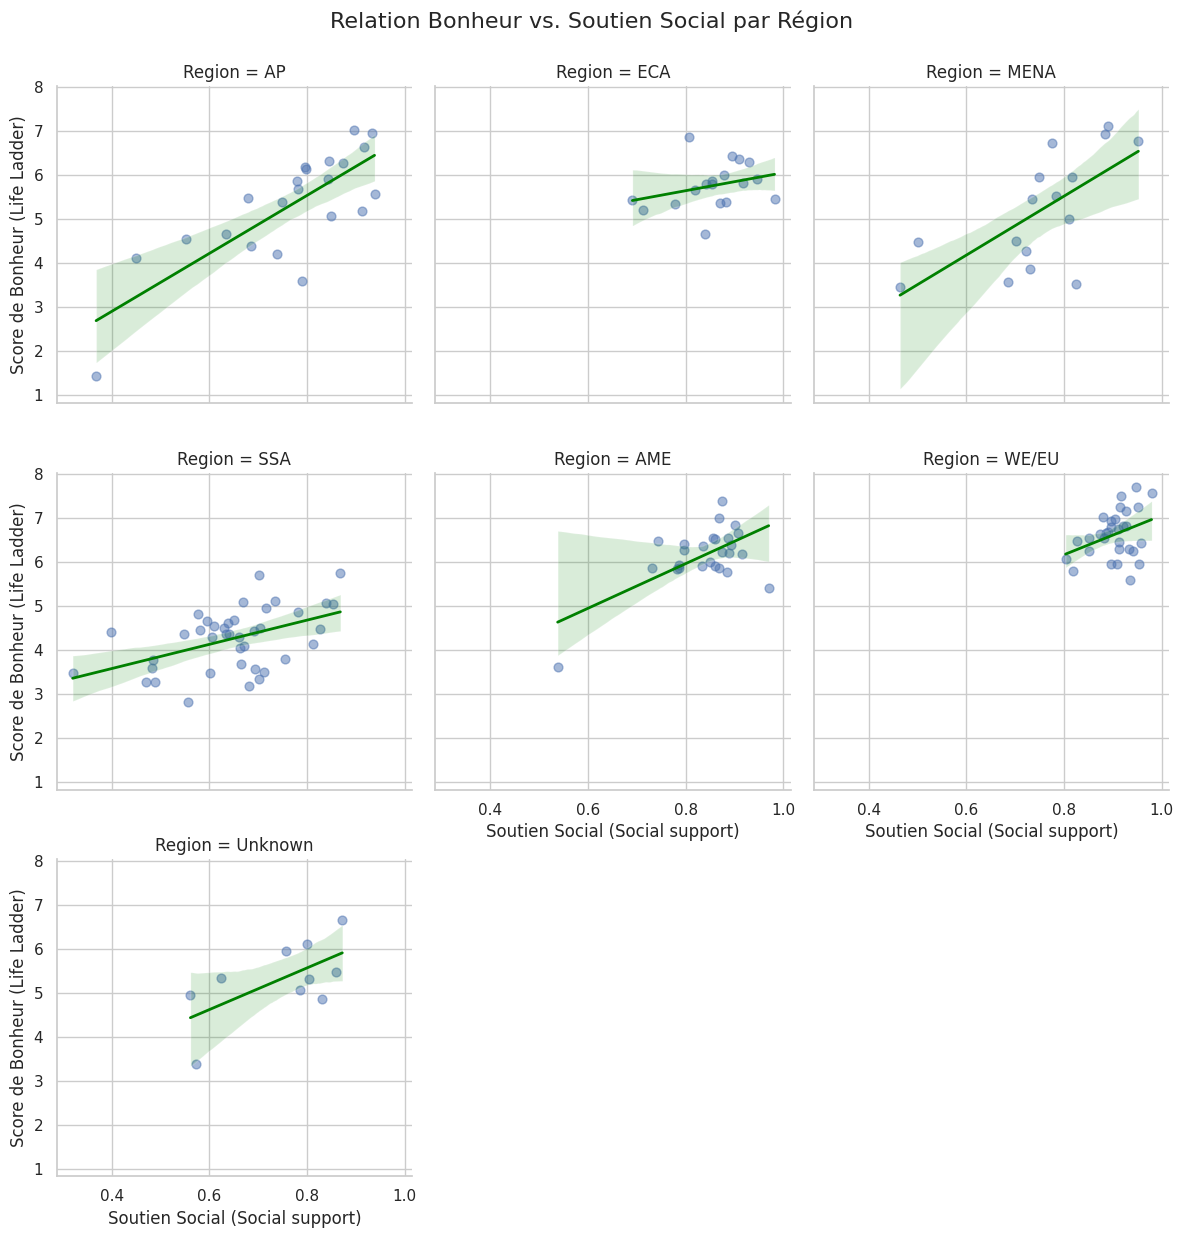

In [36]:
# --- Visualisation Q8 : Bonheur ~ Soutien Social par Région ---

if q8_data_ready_regional and 'Region' in df_q8_regional_analysis.columns and df_q8_regional_analysis['Region'].nunique() > 1:
    
    print("\nVisualisation de la relation Bonheur ~ Soutien Social par Région...")
    
    # Utiliser lmplot pour créer un graphique par région (faceting)
    g_q8_region = sns.lmplot(
        data=df_q8_regional_analysis, 
        x='Social support', 
        y='Life Ladder', 
        col='Region',        # Une colonne de graphiques par région
        col_wrap=3,          # Nombre de graphiques par ligne
        height=4,            # Hauteur de chaque graphique
        scatter_kws={'alpha': 0.5, 's': 40},
        line_kws={'color': 'green', 'linewidth': 2}
    )

    g_q8_region.fig.suptitle('Relation Bonheur vs. Soutien Social par Région', y=1.03, fontsize=16)
    g_q8_region.set_axis_labels('Soutien Social (Social support)', 'Score de Bonheur (Life Ladder)')
    plt.show()

elif not q8_data_ready_regional:
    print("Données Q8 non prêtes.")
else:
    print("Impossible de visualiser par région (colonne 'Region' non valide ou unique).")

**Interprétation (Contexte Régional Q8)**

Ces graphiques montrent la relation entre le soutien social perçu (`Social support`) et le bonheur (`Life Ladder`) pour chaque région identifiée (en ignorant le panneau 'Region Unknown' qui regroupe les pays non classifiés).

* **Tendance Générale :** Dans toutes les régions principales (AP, ECA, MENA, SSA, AME, WE/EU), la ligne de régression verte a une **pente positive très nette et forte**. Cela confirme de manière éclatante que le soutien social est universellement lié à des niveaux de bonheur plus élevés : plus le soutien social perçu est grand, plus le score de bonheur est élevé.

* **Variations Régionales (Force du lien) :** En comparant l'inclinaison des pentes, elles apparaissent **visuellement très similaires** d'une région à l'autre. Il n'y a pas de différence marquée qui suggérerait que l'importance relative du soutien social pour le bonheur varie considérablement selon le contexte régional. La force de cette association semble donc remarquablement constante.

* **Variations Régionales (Niveaux moyens) :** On observe par contre, comme attendu (cf. Q3), que les **niveaux moyens** diffèrent. Les régions WE/EU et AME se situent globalement plus haut sur les deux axes (soutien social et bonheur élevés en moyenne), tandis que les régions SSA et MENA se situent en moyenne plus bas sur ces deux dimensions. Les régions AP et ECA occupent des positions intermédiaires.

En bref, le message principal de ces graphiques est la confirmation visuelle de l'importance universelle et de la force constante du lien entre le soutien social et le bonheur à travers diverses régions du monde.

**Conclusion Générale (Question 8)**

L'analyse de la relation entre le soutien social perçu et le bonheur, en tenant compte du contexte régional (visualisée dans les graphiques ci-dessus), met en évidence deux points majeurs :

1.  **Lien Universellement Fort :** Dans **chacune des régions** identifiées (AP, ECA, MENA, SSA, AME, WE/EU), il existe une **relation positive très nette et forte** entre le `Social support` et le `Life Ladder`. La ligne de régression verte monte de manière significative partout, confirmant que le sentiment d'avoir des proches sur qui compter est un déterminant crucial du bien-être subjectif à travers le globe.

2.  **Force d'Association Similaire :** En comparant l'inclinaison (la pente) des lignes de régression vertes entre les différentes régions, on constate une **remarquable similarité visuelle**. Bien que les régions se positionnent différemment sur le graphique (certaines ayant en moyenne des niveaux plus élevés de soutien social et de bonheur que d'autres, comme WE/EU par rapport à SSA), la *force* avec laquelle une augmentation du soutien social est associée à une augmentation du bonheur semble **étonnamment constante** à travers ces contextes régionaux variés.

**Synthèse :** Le soutien social apparaît non seulement comme un pilier fondamental du bonheur partout dans le monde, mais l'intensité de son importance semble également universelle. Les différences culturelles ou de développement capturées par notre découpage régional ne paraissent pas moduler de façon majeure la force du lien entre le fait de se sentir socialement soutenu et le niveau de bonheur ressenti. Le besoin de liens sociaux solides est un ingrédient essentiel et d'importance comparable pour le bonheur humain, quelle que soit la région du monde.